# 第 7 章 · 决策树与 K-均值

50 道错题与 14 个成绩点：逐步看熵、分裂与簇中心更新。

配套交互演示：[章节网页](../ch7.html)

## 本节目标

- 计算熵与信息增益
- 理解决策树分裂
- K-均值 assign/update 循环
- 对照 ch7 网页

## 1. 错题分布

50 道题按错误类型统计：计算错误、概念混淆、粗心。根节点熵衡量不确定性。

**熵**

```text
H = -sum p_i log2 p_i
```

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd()
if not (ROOT / "labs").exists() and (ROOT.parent / "labs").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "labs"))
sys.path.insert(0, str(ROOT / "labs" / "ch07"))
import matplotlib.pyplot as plt
from common.mpl_setup import configure_matplotlib
configure_matplotlib()
from IPython.display import display, Image
from learning import *
from common.codelens import print_frames as print_codelens

In [2]:
display(error_distribution_df())

,类型,题数
0,计算错误,20
1,概念混淆,18
2,粗心,12


In [3]:
decision_tree_demo()

50 题分布: {'计算错误': 20, '概念混淆': 18, '粗心': 12}
根熵 H=1.554
分裂「含分数」→ 左叶 20 纯计算错误; 右子树 概念/粗心 [18, 12]


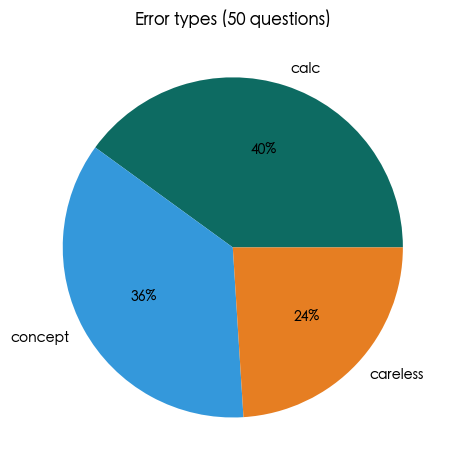

In [4]:
plot_error_pie()

**思考** · 哪类错误最多？

<details><summary>查看答案</summary>

计算错误 20 题。

</details>

## 2. 决策树分裂

### 2.1 根分裂

问「是否含分数」——左子树纯为计算错误，右子树仍混合。

纯叶节点无需再分；混合子树继续按特征分裂。

**思考** · 右子树为何还要分？

<details><summary>查看答案</summary>

概念混淆与粗心仍混合，需继续分裂。

</details>

## 3. K-均值聚类

### 3.1 迭代循环

① 每点分配到最近中心 ② 更新中心为簇内均值 ③ 直到稳定。

**K-means**

```text
repeat:
  labels = argmin ||x - mu_k||
  mu_k = mean(x in cluster k)
```

In [5]:
km_frames = codelens_kmeans()

In [6]:
print_codelens(km_frames)

── Step 0 ── 初始簇中心
   执行: init centers
   centers = [[38.0, 86.0], [74.0, 66.0]]

── Step 1 ── 第 1 轮：分配点后更新中心
   执行: assign + update mu
   labels = [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1]
   centers = [[38.7, 86.9], [73.0, 65.7]]
   cluster_sizes = [7, 7]

── Step 2 ── 第 2 轮：分配点后更新中心
   执行: assign + update mu
   labels = [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1]
   centers = [[38.7, 86.9], [73.0, 65.7]]
   cluster_sizes = [7, 7]

── Step 3 ── 第 3 轮：分配点后更新中心
   执行: assign + update mu
   labels = [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1]
   centers = [[38.7, 86.9], [73.0, 65.7]]
   cluster_sizes = [7, 7]



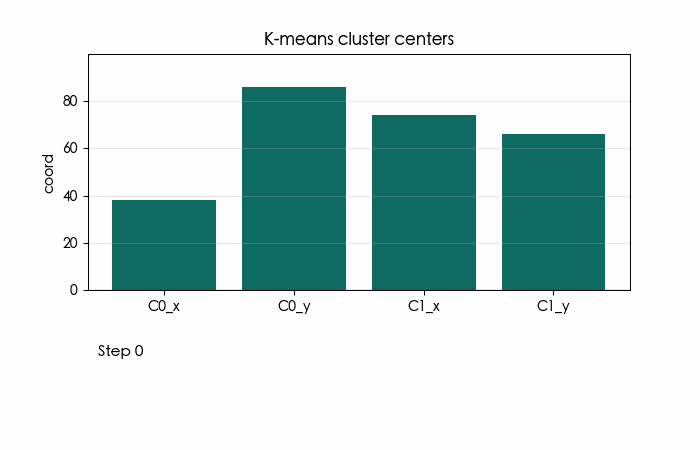

In [7]:
animate_kmeans()

In [8]:
kmeans_demo()

14 点 → 簇大小 7 + 7 (网页演示最终 6+8)
中心: [[38.7, 86.9], [73.0, 65.7]]


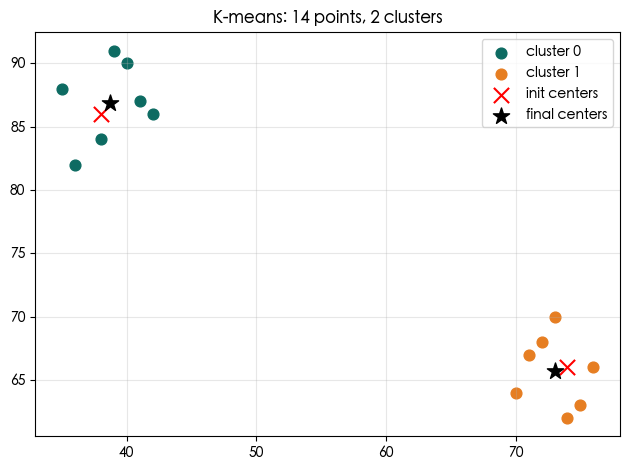

In [9]:
plot_kmeans()

**思考** · 14 点最终簇大小？

<details><summary>查看答案</summary>

约 6+8，与网页演示一致。

</details>

## 4. 两种压缩方式对比

**决策树** → 可读 if-then 规则；**K-均值** → 连续空间的簇中心。

## 小结

熵驱动树分裂；K-均值用几何距离压缩数据。

对照 [ch7.html](../ch7.html) 查看分裂与簇动画。

## 练习

1. 若三类错题数量相等，根熵是多少？
2. K=3 时 14 点会如何分配？